In [13]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
# import yfinance as yf
# import pandas as pd
# from pandas.tseries.offsets import DateOffset,BusinessDay
import seaborn as sns
# import seaborn.objects as so
# from tqdm import tqdm
# from sklearn.preprocessing import MinMaxScaler
# import math
# import sys
# sys.path.append('../..')
# #import ep.etools as apt
# # import warnings
# # warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
import tensorflow as tf
# from tensorflow.keras.optimizers import RMSprop, Adam, SGD
from tensorflow import math, matmul, reshape, shape, transpose, cast, float32
from tensorflow.keras.layers import Dense, Layer, Dropout
from tensorflow import math, cast, float32, linalg, ones, maximum, newaxis
from tensorflow import convert_to_tensor, string
# from tensorflow.keras.layers import TextVectorization, Embedding
# from tensorflow.data import Dataset
from keras.backend import softmax
# from keras import Input
# from keras import layers, Model

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# import myData as myD


In [2]:
def padding_mask( input):
    # Create mask which marks the zero padding values in the input by a 1.0
    mask = math.equal(input, 0)
    print(mask)
    mask = cast(mask, float32)
    print(mask)

    # The shape of the mask should be broadcastable to the shape
    # of the attention weights that it will be masking later on
    return mask[:, newaxis, newaxis, :]

In [3]:
def lookahead_mask(shape):
    # Mask out future entries by marking them with a 1.0
    mask = 1 - linalg.band_part(ones((shape, shape)), -1, 0)

    return mask*(-1e9)

In [5]:
# Implementing Dot Product - return Values/Weights
class DotProduct(Layer):
    def __init__(self, **kwargs):
        super(DotProduct, self).__init__(**kwargs)
 
    def call(self, queries, keys, values, mask=None):
        d_k=queries.shape[-1]
        # Scoring the queries against the keys after transposing the latter, and scaling
        scores = matmul(queries, keys, transpose_b=True) / math.sqrt(cast(d_k, float32))
        # Apply mask to the attention scores
        if mask is not None:
            scores += mask
        # Computing the weights by a softmax operation
        weights = softmax(scores)
        # Computing the attention by a weighted sum of the value vectors
        return matmul(weights, values),weights
    
# # PYTORCH
# def scaled_dot_product(q, k, v, mask=None):
#     d_k = cast(q.size(-1),tf.float32)
#     print('ici',math.sqrt(d_k))
#     # print(k.transpose(-1,-2))
#     scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
#     if mask is not None:
#         scaled += mask
#     attention = F.softmax(scaled, dim=-1)
#     values = torch.matmul(attention, v)
#     return values, attention

In [76]:
# Implementing the Multi-Head Attention
class MultiHeadAttention(Layer):
    def __init__(self, h, d_model, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.attention = DotProduct()  # Scaled dot product attention
        self.heads = h  # Number of attention heads to use
        self.head_dim = int(d_model / h)
        self.d_model = d_model  # Dimensionality of the model
        self.qkv_layer = Dense(3*d_model)  # Learned projection matrix for the queries
        self.dense = Dense(d_model)  # Learned projection matrix for the multi-head output
  
    def call(self, x, mask=None):
        # Rearrange the queries to be able to compute all heads in parallel
        # print('queries',queries.shape)
        # print('Dense(q)',self.W_q(queries).shape)
        batch_size = x.shape[0]
        seq_lenght = x.shape[1]
        input_dim = x.shape[2]
        qkv = self.qkv_layer(x)
        qkv = tf.reshape(qkv,shape=[batch_size , seq_lenght , self.heads , int(3*self.head_dim)])
        qkv = transpose(qkv,perm=(0,2,1,3))
        # print(qkv.shape, batch_size , self.heads, seq_lenght , self.head_dim)
        q = tf.slice(qkv,[0,0,0,0],[batch_size,self.heads,seq_lenght,self.head_dim])
        k = tf.slice(qkv,[0,0,0,self.head_dim],[batch_size,self.heads,seq_lenght,self.head_dim])
        v = tf.slice(qkv,[0,0,0,int(2*self.head_dim)],[batch_size,self.heads,seq_lenght,self.head_dim])
 
        # # Compute the multi-head attention output using the reshaped queries, keys and values
        attention, weights = self.attention(q, k, v, mask)
        print('attention',attention.shape)
        attention = tf.transpose(attention,perm=(0,2,1,3))
        attention = tf.reshape(attention,shape=[batch_size,seq_lenght,int(self.heads*self.head_dim)])

        # # Apply one final linear projection to the output to generate the multi-head attention
        # # Resulting tensor shape: (batch_size, input_seq_length, d_model)
        # return attention
        return attention,weights

(20, 20)
attention (32, 8, 20, 64)
(32, 20, 512) (32, 8, 20, 20)


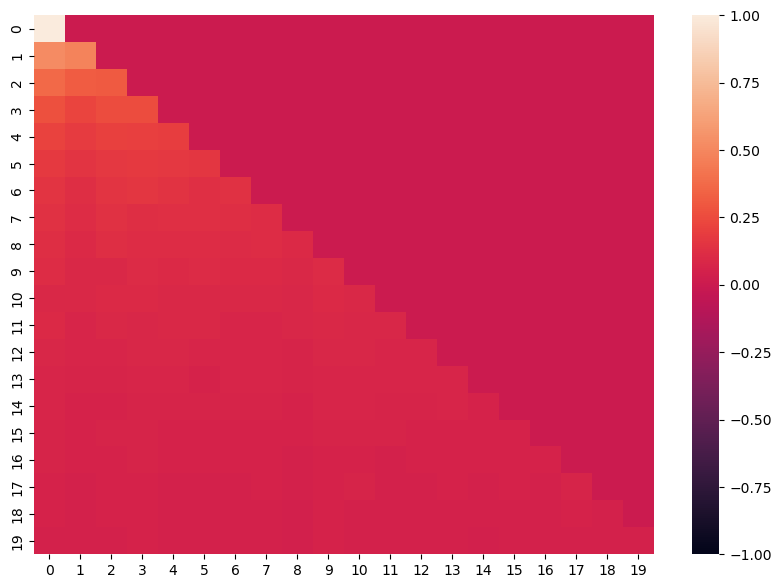

In [88]:
# TEST DOT PRODUCT
input_seq_length = 20  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of the model sub-layers' outputs
batch_size = 32  # Batch size from the training process
 
queries = random.random((batch_size, input_seq_length, d_model))
q = tf.convert_to_tensor(queries, dtype=tf.float32)
# keys = random.random((batch_size, input_seq_length, d_k))
# values = random.random((batch_size, input_seq_length, d_v))

# queries = queries.reshape((batch_size,1,input_seq_length, d_k))
# keys = keys.reshape((batch_size,1,input_seq_length, d_k))
# values = values.reshape((batch_size,1,input_seq_length, d_v))

# q = torch.randn((batch_size,1,input_seq_length, d_model))
# k = torch.randn((batch_size,1,input_seq_length, d_k))
# v = torch.randn((batch_size,1,input_seq_length, d_v))
# print(k.transpose(-1,-2).shape)

# DP = DotProduct()
MH = MultiHeadAttention(h,d_model)
mask = lookahead_mask(int(input_seq_length))
print(mask.shape)
# attention, weights = DP(queries,keys,values,mask)
attention,weights = MH(q,mask)
print(attention.shape,weights.shape)
fig = plt.figure(figsize=(10,7))
sns.heatmap(weights[10][7], vmin=-1, vmax=1);
# print(weights[1][1])
# sns.heatmap(mask);

# Tattention, Tweights = scaled_dot_product(q,k,v)
# print(Tattention.shape)

In [67]:
print(attention.shape)
# q,k,v = tf.split(attention, [32,8,20,192],3)
q = tf.slice(attention,[0,0,0,0],[32,8,20,64])
k = tf.slice(attention,[0,0,0,64],[32,8,20,64])
v = tf.slice(attention,[0,0,0,128],[32,8,20,64])
print(q.shape, k.shape, v.shape)


(32, 8, 20, 192)
(32, 8, 20, 64) (32, 8, 20, 64) (32, 8, 20, 64)
